# 01 — EDA: Raw Transaction Data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_SEED = 42
DATA_DIR = Path('..') / 'data' / 'raw'

pd.set_option('display.max_columns', 100)


## 1. Load Data

In [12]:
df = pd.read_csv(DATA_DIR / 'ecommerce_customer_data_large.csv')
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.shape)
df.head(10)

(250000, 13)


,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,age,gender,churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0
5,13738,2022-08-25 06:48:33,Home,191,3,3722,Credit Card,27,1.0,Lauren Johnson,27,Female,0
6,13738,2023-07-25 05:17:24,Electronics,205,1,2773,Credit Card,27,NaN,Lauren Johnson,27,Female,0
7,13738,2023-02-05 19:31:48,Books,370,5,1486,Cash,27,1.0,Lauren Johnson,27,Female,0
8,13738,2021-12-21 03:29:05,Home,12,2,2175,Cash,27,NaN,Lauren Johnson,27,Female,0
9,13738,2023-02-09 00:53:14,Electronics,40,4,4327,Cash,27,0.0,Lauren Johnson,27,Female,0


In [13]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

print(f'Unique product categories ({df["product_category"].nunique()}): {df["product_category"].unique().tolist()}')
print(f'Purchase date range : {df["purchase_date"].min().date()} → {df["purchase_date"].max().date()}')
print(f'Unique payment methods ({df["payment_method"].nunique()}): {df["payment_method"].unique().tolist()}')

Unique product categories (4): ['Home', 'Electronics', 'Books', 'Clothing']
Purchase date range : 2020-01-01 → 2023-09-13
Unique payment methods (3): ['PayPal', 'Credit Card', 'Cash']


## 2. Schema & Data Types

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   customer_id            250000 non-null  int64         
 1   purchase_date          250000 non-null  datetime64[ns]
 2   product_category       250000 non-null  object        
 3   product_price          250000 non-null  int64         
 4   quantity               250000 non-null  int64         
 5   total_purchase_amount  250000 non-null  int64         
 6   payment_method         250000 non-null  object        
 7   customer_age           250000 non-null  int64         
 8   returns                202618 non-null  float64       
 9   customer_name          250000 non-null  object        
 10  age                    250000 non-null  int64         
 11  gender                 250000 non-null  object        
 12  churn                  250000 non-null  int6

## 3. Missing Values

In [15]:
missing_prct = df.isnull().mean() * 100
missing_prct

customer_id               0.0000
purchase_date             0.0000
product_category          0.0000
product_price             0.0000
quantity                  0.0000
total_purchase_amount     0.0000
payment_method            0.0000
customer_age              0.0000
returns                  18.9528
customer_name             0.0000
age                       0.0000
gender                    0.0000
churn                     0.0000
dtype: float64

## 4. Consistency Checks

In [16]:
# 4a. Each customer should have a single churn label (not a mix of 0 and 1)
churn_per_customer = df.groupby('customer_id')['churn'].nunique()
inconsistent_churn = churn_per_customer[churn_per_customer > 1]
print(f'Customers with mixed churn labels : {len(inconsistent_churn)} (expected 0)')

# 4b. customer_age and age columns should be identical
age_mismatch = (df['customer_age'] != df['age']).sum()
print(f'Rows where customer_age != age    : {age_mismatch} (expected 0)')

# 4c. returns should only contain 0, 1, or NaN
unexpected_returns = df['returns'].dropna()
unexpected_returns = unexpected_returns[~unexpected_returns.isin([0, 1])]
print(f'Unexpected values in returns      : {len(unexpected_returns)} (expected 0)')

# 4d. product_price, quantity, total_purchase_amount must be positive
for col in ['product_price', 'quantity', 'total_purchase_amount']:
    bad = (df[col] <= 0).sum()
    print(f'Non-positive values in {col:<25}: {bad} (expected 0)')

# 4e. customer_age within valid range [16, 85]
out_of_range = df[(df['customer_age'] < 16) | (df['customer_age'] > 85)]
print(f'Ages outside [16, 85]             : {len(out_of_range)} (expected 0)')

# 4f. Duplicate rows
duplicates = df.duplicated().sum()
print(f'Exact duplicate rows              : {duplicates} (expected 0)')

Customers with mixed churn labels : 0 (expected 0)
Rows where customer_age != age    : 0 (expected 0)
Unexpected values in returns      : 0 (expected 0)
Non-positive values in product_price            : 0 (expected 0)
Non-positive values in quantity                 : 0 (expected 0)
Non-positive values in total_purchase_amount    : 0 (expected 0)
Ages outside [16, 85]             : 0 (expected 0)
Exact duplicate rows              : 0 (expected 0)


## 5. Target Distribution

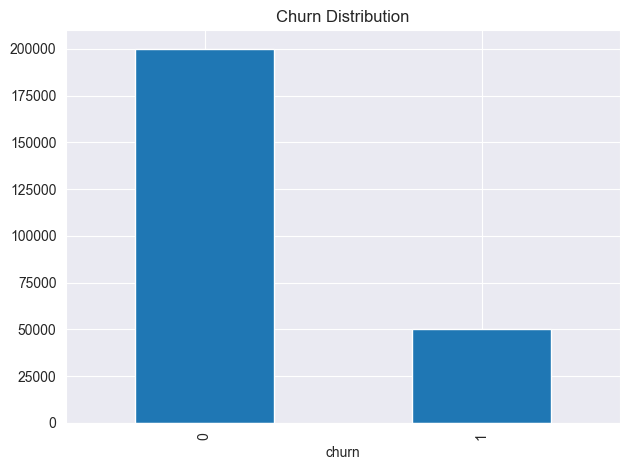

churn
0    0.799
1    0.201
Name: proportion, dtype: float64


In [17]:
target_col = 'churn'
ax = df[target_col].value_counts().plot(kind='bar')
ax.set_title('Churn Distribution')
plt.tight_layout()
plt.show()
print(df[target_col].value_counts(normalize=True).round(3))

## 6. Numeric Feature Distributions

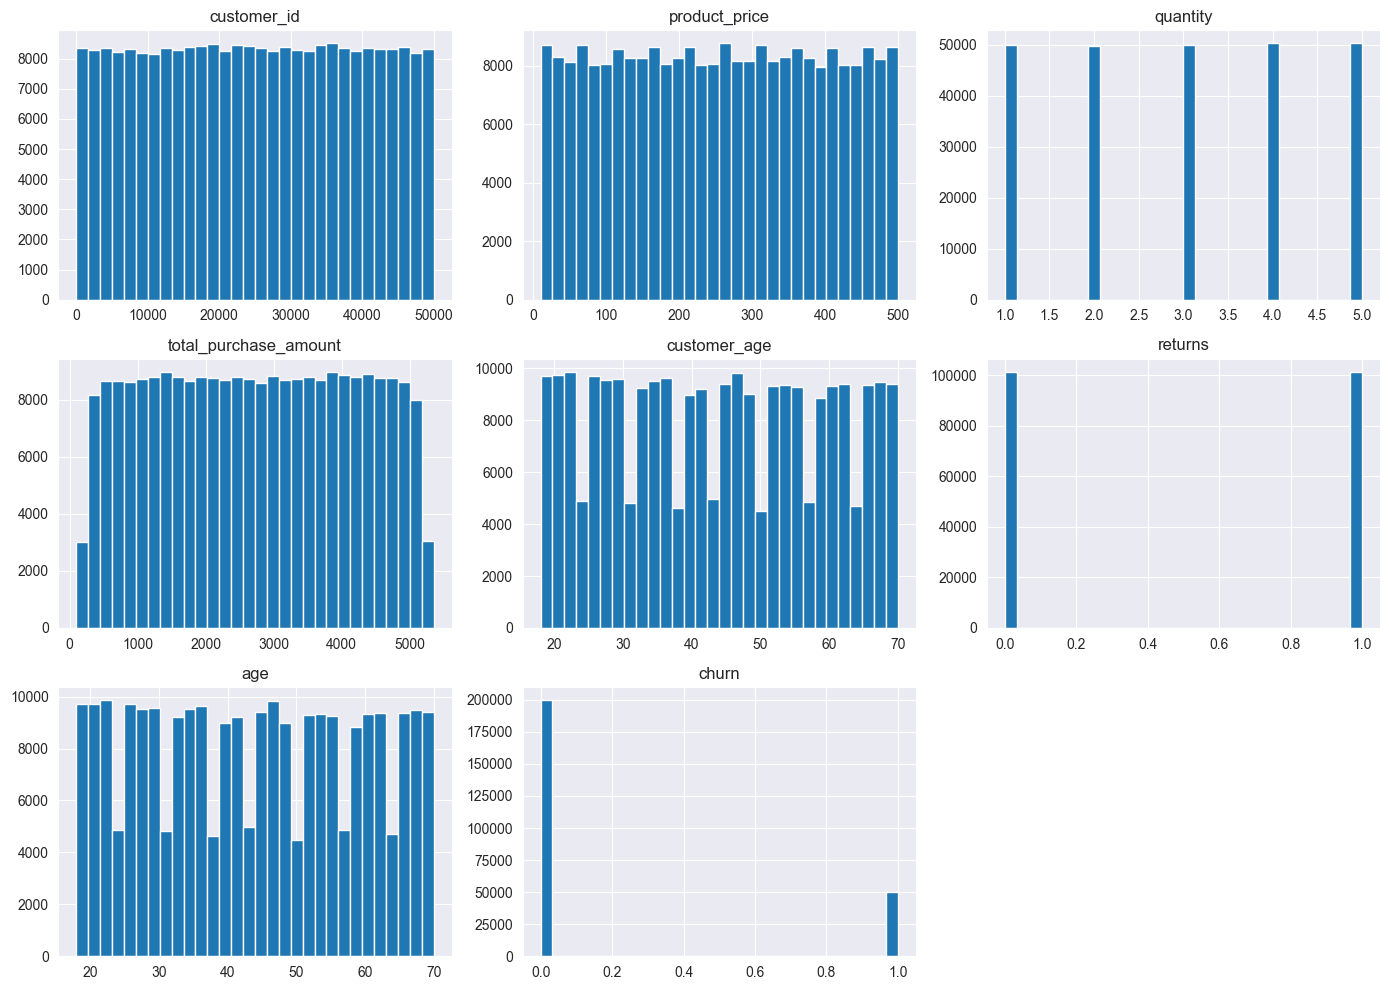

In [18]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap (transaction-level)

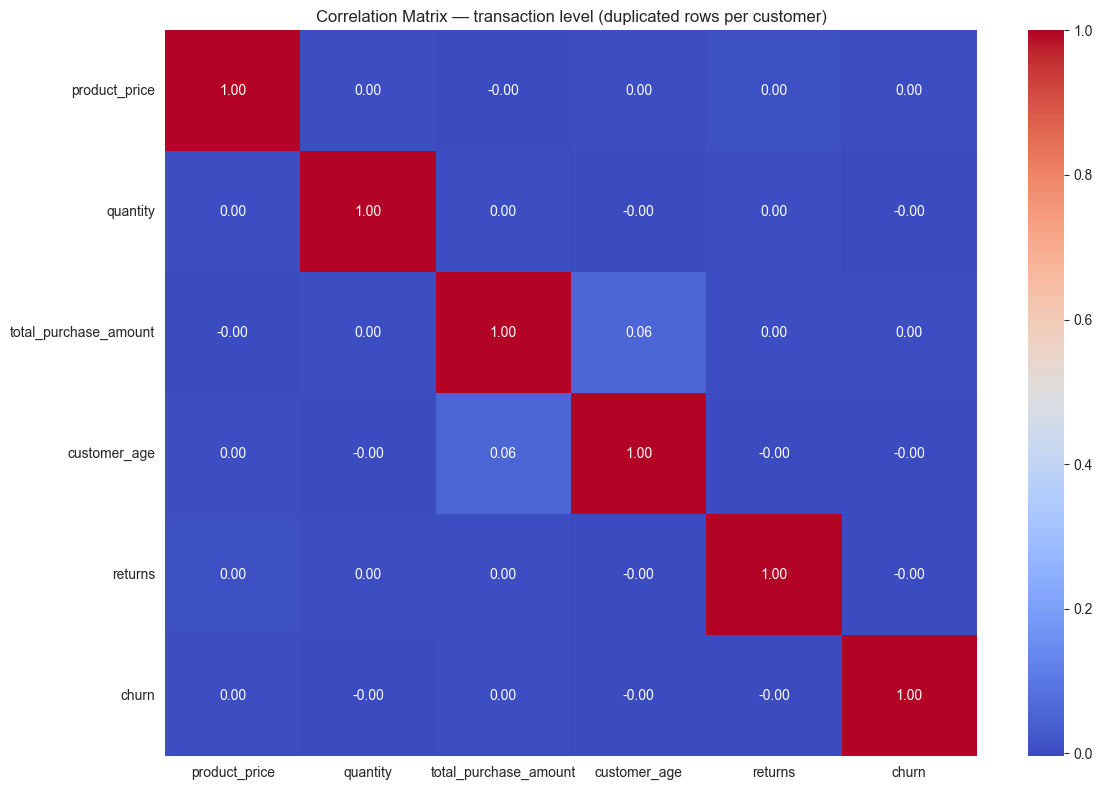

In [19]:
exclude = ['customer_id', 'age']
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in exclude]

plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix — transaction level (duplicated rows per customer)')
plt.tight_layout()
plt.show()


## 8. Categorical Features vs Churn

In [20]:
cat_cols = [c for c in df.select_dtypes(include='object').columns
            if c not in ('customer_name', 'purchase_date')]
for col in cat_cols:
    ct = pd.crosstab(df[col], df[target_col], normalize='index').round(3)
    print(f'\n--- {col} ---')
    print(ct)



--- product_category ---
churn                 0      1
product_category              
Books             0.799  0.201
Clothing          0.799  0.201
Electronics       0.800  0.200
Home              0.800  0.200

--- payment_method ---
churn               0      1
payment_method              
Cash            0.797  0.203
Credit Card     0.803  0.197
PayPal          0.798  0.202

--- gender ---
churn       0      1
gender              
Female  0.798  0.202
Male    0.801  0.199
